In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [6]:
df = pd.read_csv("/Users/jennaqasqas/python_decal_sp26/course_assignments/homework9/noisy_curvefit_data.csv")

In [7]:
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst five rows:")
print(df.head())

print("\nLast five rows:")
print(df.tail())

print("\nColumn names:")
print(df.columns)

Shape of dataset: (100, 6)
Number of rows: 100
Number of columns: 6

First five rows:
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113

Last five rows:
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

Column names:
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise

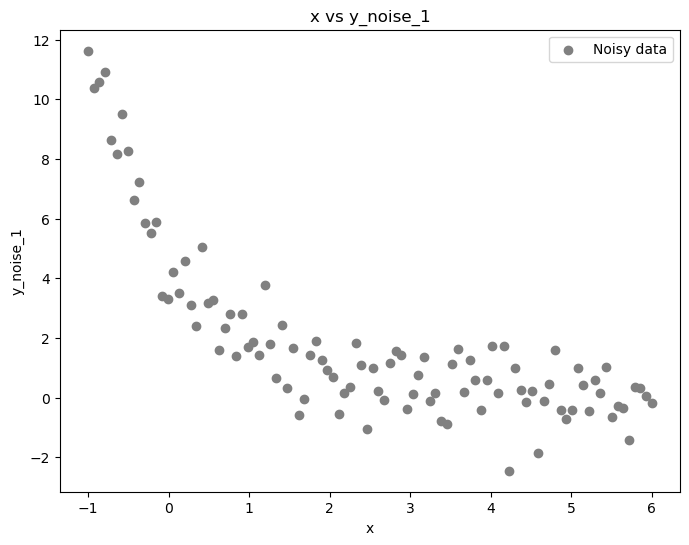

In [9]:
x = df["x"]
y_noise_1 = df["y_noise_1"]
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noise_1, color="gray", label="Noisy data")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title("x vs y_noise_1")
plt.legend()
plt.show()

In [11]:
def model(x, A, k):
    return A * np.exp(-k * x)

In [14]:
p0 = [1,1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

A_fit, k_fit = popt
f"Fit: y_noise_1 = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"

'Fit: y_noise_1 = 4.71 * e^(-0.92 * x)'

In [19]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

print("residuals:", residuals)
print("reduced chi squared:", chi2_reduced)

residuals: 0    -0.186416
1    -0.690848
2     0.212626
3     1.193548
4    -0.468995
        ...   
95   -1.436656
96    0.321697
97    0.285407
98    0.028297
99   -0.212518
Length: 100, dtype: float64
reduced chi squared: 0.7906732087457324


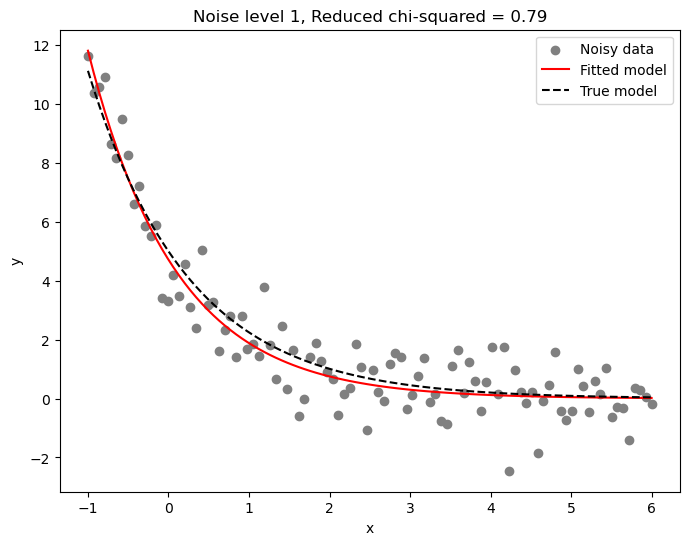

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noise_1, color="gray", label="Noisy data")
plt.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
plt.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True model")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise level 1, Reduced chi-squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [28]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return A_fit, k_fit, chi2_reduced

    results = []
    for i in range(1, 6):
        y = df[f"y_noise_{i}"]
        A_fit, k_fit, chi2_reduced = fit_model(x, y)
        results.append([i, A_fit, k_fit, chi2_reduced])

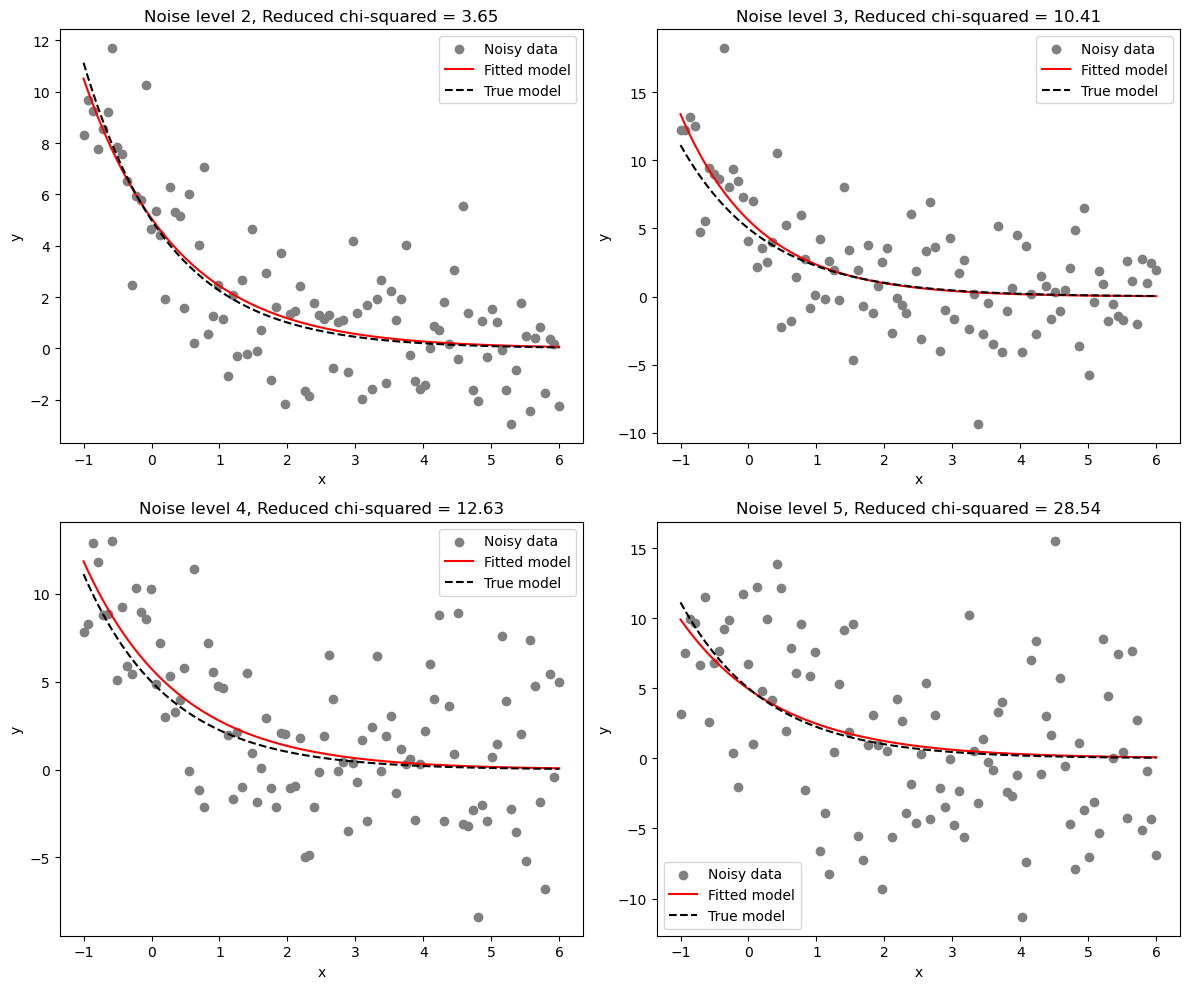

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, i in zip(axes, range(2, 6)):
    y = df[f"y_noise_{i}"]
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    ax.scatter(x, y, color="gray", label="Noisy data")
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
    ax.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True model")
    
    ax.set_title(f"Noise level {i}, Reduced chi-squared = {chi2_reduced:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()

4. As the noise level increases, the red fitted line moves farther away from the black dotted true model. This is because larger noise makes the data more scattered and the fit is less accurate. As the noise level increases, the reduced chi-squared increases because residuals are getting larger so the model doesn't match as well.

In [34]:
results_df = pd.DataFrame(results, columns=["Noise level", "A fit", "k fit", "Reduced chi-squared"])
print(results_df)

   Noise level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


In [33]:
results = []

for i in range(1, 6):
    y = df[f"y_noise_{i}"]
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    results.append([i, A_fit, k_fit, chi2_reduced])

In [35]:
results_df.to_csv("noisy_parameters.csv", index=False)